# IMU Prediction

## Error state Kalman filter in brief
In error-state filter formulations, we speak of true-, nominal- and error-state values, the true-state being expressed as a suitable composition (linear sum, quaternion product or matrix product) of the nominal- and the error- states. The idea is to consider the nominal-state as large-signal (integrable in non-linear fashion) and the error-state as small signal (thus linearly integrable and suitable for linear-Gaussian filtering).

The error-state filter can be explained as follows. On one side, high-frequency IMU data $u_{m}$ is integrated into a nominal-state $x$. This nominal state does not take into account the
noise terms $w$ and other possible model imperfections. As a consequence, it will accumulate errors. These errors are collected in the error-state $δx$ and estimated with the Error-State Kalman Filter (ESKF), this time incorporating all the noise and perturbations. The error-state consists of small-signal magnitudes, and its evolution function is correctly defined by a (time-variant) linear dynamic system, with its dynamic, control and measurement matrices computed from the values of the nominal-state. In parallel with integration of the nominal-state, the ESKF predicts a Gaussian estimate of the error-state. It only predicts, because by now no other measurement is available to correct these estimates. The filter correction is performed at the arrival of information other than IMU (e.g. GPS, vision, etc.), which is able to render the errors observable and which happens generally at a much lower rate than the integration phase. This correction provides a posterior Gaussian estimate of the error-state. After this, the error-state’s mean is injected into the nominal-state, then reset to zero. The error-state’s covariances matrix is conveniently updated to reflect this reset. The system goes on like this forever.

The simplified ESKF goes like this:
1. Use IMU to propagate mean simply by ignoring noise
2. Error state equations give you state transition and noise jacobians. These are only needed for covariance propagation. Mean of error state is zero. 
3. Update step updates the covariance using measurement jacobians and the mean error state which is injected into the mean as the next estimate.

### Solas Prediction
Note: Sola uses Hamilton convention. Please check the assumptions in Solas paper.

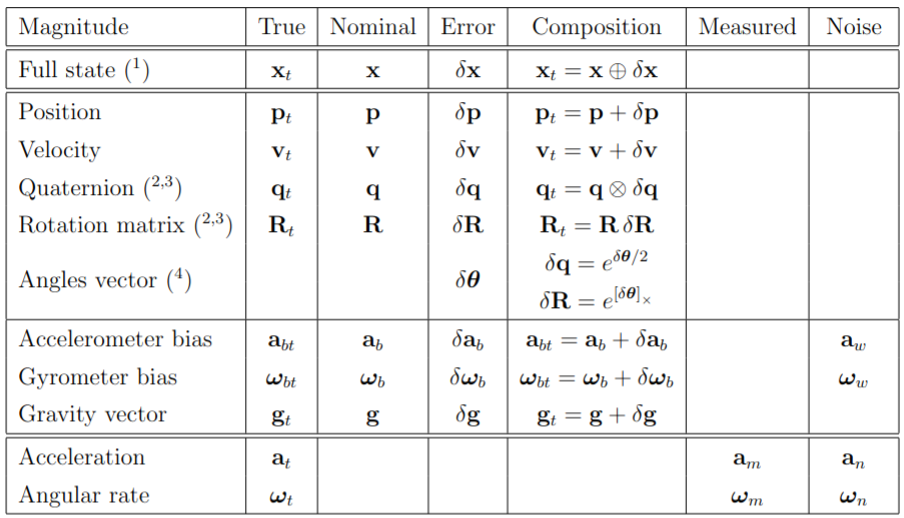


For continuos system of equations:
#### True state Kinematics
The true acceleration $\mathbf{a}_t$ and angular rate $\omega_t$ are obtained from an IMU in the form of noisy sensor readings $\mathbf{a}_m$ and $\omega_m$ in body frame, namely:

$$\mathbf{a}_m = \mathbf{R}_t^\top (\mathbf{a}_t - \mathbf{g}_t) + \mathbf{a}_{bt} + \mathbf{a}_n $$
$$\omega_m = \omega_t + \omega_{bt} + \omega_n $$

with $\mathbf{R}_t \triangleq \mathbf{R}\{\mathbf{q}_t\}$. With this, the true values can be isolated (this means that we have inverted the measurement equations),

$$\mathbf{a}_t = \mathbf{R}_t(\mathbf{a}_m - \mathbf{a}_{bt} - \mathbf{a}_n) + \mathbf{g}_t $$
$$\omega_t = \omega_m - \omega_{bt} - \omega_n $$

Substituting above yields the kinematic system

$$\dot{\mathbf{p}}_t = \mathbf{v}_t $$
$$\dot{\mathbf{v}}_t = \mathbf{R}_t(\mathbf{a}_m - \mathbf{a}_{bt} - \mathbf{a}_n) + \mathbf{g}_t $$
$$\dot{\mathbf{q}}_t = \frac{1}{2} \mathbf{q}_t \otimes (\omega_m - \omega_{bt} - \omega_n) $$
$$\dot{\mathbf{a}}_{bt} = \mathbf{a}_w $$
$$\dot{\omega}_{bt} = \omega_w $$
$$\dot{\mathbf{g}}_t = 0 $$

which we may name $\dot{\mathbf{x}}_t = f_t(\mathbf{x}_t, \mathbf{u}, \mathbf{w})$. This system has state $\mathbf{x}_t$, is governed by IMU noisy readings $\mathbf{u}_m$, and is perturbed by white Gaussian noise $\mathbf{w}$, all defined by

$$\mathbf{x}_t = \begin{bmatrix} \mathbf{p}_t \\ \mathbf{v}_t \\ \mathbf{q}_t \\ \mathbf{a}_{bt} \\ \omega_{bt} \\ \mathbf{g}_t \end{bmatrix} \quad \mathbf{u} = \begin{bmatrix} \mathbf{a}_m - \mathbf{a}_n \\ \omega_m - \omega_n \end{bmatrix} \quad \mathbf{w} = \begin{bmatrix} \mathbf{a}_w \\ \omega_w \end{bmatrix} $$

#### Nominal state Kinematics

The nominal-state kinematics corresponds to the modeled system without noises or perturbations,

$$\dot{\mathbf{p}} = \mathbf{v} $$
$$\dot{\mathbf{v}} = \mathbf{R}(\mathbf{a}_m - \mathbf{a}_b) + \mathbf{g} $$
$$\dot{\mathbf{q}} = \frac{1}{2} \mathbf{q} \otimes (\omega_m - \omega_b) $$
$$\dot{\mathbf{a}}_b = 0 $$
$$\dot{\omega}_b = 0 $$
$$\dot{\mathbf{g}} = 0. $$

#### Error-state kinematics

The goal is to determine the linearized dynamics of the error-state. For each state equation, we write its composition, linearizing wherever needed, solving for the error state and simplifying all second-order infinitesimals.

$$\dot{\delta \mathbf{p}} = \delta \mathbf{v} $$
$$\dot{\delta \mathbf{v}} = -\mathbf{R} \lfloor \mathbf{a}_m - \mathbf{a}_b \rfloor_\times \delta \theta - \mathbf{R} \delta \mathbf{a}_b + \delta \mathbf{g} - \mathbf{R} \mathbf{a}_n $$
$$\dot{\delta \theta} = -\lfloor \omega_m - \omega_b \rfloor_\times \delta \theta - \delta \omega_b - \omega_n $$
$$\dot{\delta \mathbf{a}}_b = \mathbf{a}_w $$
$$\dot{\delta \omega}_b = \omega_w $$
$$\dot{\delta \mathbf{g}} = 0. $$

Now we move to discrete case:
#### True state Kinematics
The above true state kinematics for the continuous case can be converted to true state by converting those equations into difference equations. It should be straightforward.

#### Nominal state Kinematics
We can write the differences equations of the nominal-state as

$$\mathbf{p} \leftarrow \mathbf{p} + \mathbf{v} \Delta t + \frac{1}{2}(\mathbf{R}(\mathbf{a}_m - \mathbf{a}_b) + \mathbf{g}) \Delta t^2 $$
$$\mathbf{v} \leftarrow \mathbf{v} + (\mathbf{R}(\mathbf{a}_m - \mathbf{a}_b) + \mathbf{g}) \Delta t $$
$$\mathbf{q} \leftarrow \mathbf{q} \otimes \mathbf{q} \{ (\omega_m - \omega_b) \Delta t \} $$
$$\mathbf{a}_b \leftarrow \mathbf{a}_b $$
$$\omega_b \leftarrow \omega_b $$
$$\mathbf{g} \leftarrow \mathbf{g}, $$

where $x \leftarrow f(x, \bullet)$ stands for a time update of the type $x_{k+1} = f(x_k, \bullet_k)$, $\mathbf{R} \triangleq \mathbf{R}\{\mathbf{q}\}$ is the rotation matrix associated to the current nominal orientation $\mathbf{q}$, and $\mathbf{q}\{v\}$ is the quaternion associated to the rotation $v$.

We can also use more precise integration. Check RK4 methods.

#### Error-state kinematics

The deterministic part is integrated normally, and the integration of the stochastic part results in random impulses, thus,

$$\delta \mathbf{p} \leftarrow \delta \mathbf{p} + \delta \mathbf{v} \Delta t $$
$$\delta \mathbf{v} \leftarrow \delta \mathbf{v} + (-\mathbf{R} \lfloor \mathbf{a}_m - \mathbf{a}_b \rfloor_\times \delta \theta - \mathbf{R} \delta \mathbf{a}_b + \delta \mathbf{g}) \Delta t + \mathbf{v}_{\mathbf{i}} $$
$$\delta \theta \leftarrow \mathbf{R}^\top \{ (\omega_m - \omega_b) \Delta t \} \delta \theta - \delta \omega_b \Delta t + \theta_{\mathbf{i}} $$
$$\delta \mathbf{a}_b \leftarrow \delta \mathbf{a}_b + \mathbf{a}_{\mathbf{i}} $$
$$\delta \omega_b \leftarrow \delta \omega_b + \omega_{\mathbf{i}} $$
$$\delta \mathbf{g} \leftarrow \delta \mathbf{g}. $$

Here, $\mathbf{v}_{\mathbf{i}}$, $\theta_{\mathbf{i}}$, $\mathbf{a}_{\mathbf{i}}$ and $\omega_{\mathbf{i}}$ are the random impulses applied to the velocity, orientation and bias estimates, modeled by white Gaussian processes. Their mean is zero, and their covariances matrices are obtained by integrating the covariances of $\mathbf{a}_n, \omega_n, \mathbf{a}_w$ and $\omega_w$ over the step time $\Delta t$,

$$\mathbf{V}_{\mathbf{i}} = \sigma_{\mathbf{a}_n}^2 \Delta t^2 \mathbf{I} \quad [m^2/s^2] $$
$$\Theta_{\mathbf{i}} = \sigma_{\omega_n}^2 \Delta t^2 \mathbf{I} \quad [rad^2] $$
$$\mathbf{A}_{\mathbf{i}} = \sigma_{\mathbf{a}_w}^2 \Delta t \mathbf{I} \quad [m^2/s^4] $$
$$\Omega_{\mathbf{i}} = \sigma_{\omega_w}^2 \Delta t \mathbf{I} \quad [rad^2/s^2] $$

where $\sigma_{\mathbf{a}_n} [m/s^2]$, $\sigma_{\omega_n} [rad/s]$, $\sigma_{\mathbf{a}_w} [m/s^2\sqrt{s}]$ and $\sigma_{\omega_w} [rad/s\sqrt{s}]$ are to be determined from the information in the IMU datasheet, or from experimental measurements.

#### Error-state Jacobian and perturbation matrices

The Jacobians are obtained by simple inspection of the error-state differences equations in the previous section.

To write these equations in compact form, we consider the nominal state vector $\mathbf{x}$, the error state vector $\delta \mathbf{x}$, the input vector $\mathbf{u}_m$, and the perturbation impulses vector $\mathbf{i}$, as follows,

$$\mathbf{x} = \begin{bmatrix} \mathbf{p} \\ \mathbf{v} \\ \mathbf{q} \\ \mathbf{a}_b \\ \omega_b \\ \mathbf{g} \end{bmatrix} , \quad \delta \mathbf{x} = \begin{bmatrix} \delta \mathbf{p} \\ \delta \mathbf{v} \\ \delta \theta \\ \delta \mathbf{a}_b \\ \delta \omega_b \\ \delta \mathbf{g} \end{bmatrix} , \quad \mathbf{u}_m = \begin{bmatrix} \mathbf{a}_m \\ \omega_m \end{bmatrix} , \quad \mathbf{i} = \begin{bmatrix} \mathbf{v}_{\mathbf{i}} \\ \theta_{\mathbf{i}} \\ \mathbf{a}_{\mathbf{i}} \\ \omega_{\mathbf{i}} \end{bmatrix} $$

The error-state system is now

$$\delta \mathbf{x} \leftarrow f(\mathbf{x}, \delta \mathbf{x}, \mathbf{u}_m, \mathbf{i}) = \mathbf{F}_{\mathbf{x}}(\mathbf{x}, \mathbf{u}_m) \cdot \delta \mathbf{x} + \mathbf{F}_{\mathbf{i}} \cdot \mathbf{i}, $$

The ESKF prediction equations are written:

$$\hat{\delta \mathbf{x}} \leftarrow \mathbf{F}_{\mathbf{x}}(\mathbf{x}, \mathbf{u}_m) \cdot \hat{\delta \mathbf{x}} $$
$$\mathbf{P} \leftarrow \mathbf{F}_{\mathbf{x}} \mathbf{P} \mathbf{F}_{\mathbf{x}}^\top + \mathbf{F}_{\mathbf{i}} \mathbf{Q}_{\mathbf{i}} \mathbf{F}_{\mathbf{i}}^\top , $$

where $\delta \mathbf{x} \sim \mathcal{N}\{\hat{\delta \mathbf{x}}, \mathbf{P}\}^{25}$; $\mathbf{F}_{\mathbf{x}}$ and $\mathbf{F}_{\mathbf{i}}$ are the Jacobians of $f()$ with respect to the error and perturbation vectors; and $\mathbf{Q}_{\mathbf{i}}$ is the covariances matrix of the perturbation impulses.

The expressions of the Jacobian and covariances matrices above are detailed below. All state-related values appearing herein are extracted directly from the nominal state.

$$\mathbf{F}_{\mathbf{x}} = \left. \frac{\partial f}{\partial \delta \mathbf{x}} \right|_{\mathbf{x}, \mathbf{u}_m} = \begin{bmatrix} 
\mathbf{I} & \mathbf{I} \Delta t & 0 & 0 & 0 & 0 \\ 
0 & \mathbf{I} & -\mathbf{R} \lfloor \mathbf{a}_m - \mathbf{a}_b \rfloor_\times \Delta t & -\mathbf{R} \Delta t & 0 & \mathbf{I} \Delta t \\ 
0 & 0 & \mathbf{R}^\top \{ (\omega_m - \omega_b) \Delta t \} & 0 & -\mathbf{I} \Delta t & 0 \\ 
0 & 0 & 0 & \mathbf{I} & 0 & 0 \\ 
0 & 0 & 0 & 0 & \mathbf{I} & 0 \\ 
0 & 0 & 0 & 0 & 0 & \mathbf{I} 
\end{bmatrix} $$

$$\mathbf{F}_{\mathbf{i}} = \left. \frac{\partial f}{\partial \mathbf{i}} \right|_{\mathbf{x}, \mathbf{u}_m} = \begin{bmatrix} 
0 & 0 & 0 & 0 \\ 
\mathbf{I} & 0 & 0 & 0 \\ 
0 & \mathbf{I} & 0 & 0 \\ 
0 & 0 & \mathbf{I} & 0 \\ 
0 & 0 & 0 & \mathbf{I} \\ 
0 & 0 & 0 & 0 
\end{bmatrix} \quad , \quad \mathbf{Q}_{\mathbf{i}} = \begin{bmatrix} 
\mathbf{V}_{\mathbf{i}} & 0 & 0 & 0 \\ 
0 & \Theta_{\mathbf{i}} & 0 & 0 \\ 
0 & 0 & \mathbf{A}_{\mathbf{i}} & 0 \\ 
0 & 0 & 0 & \Omega_{\mathbf{i}} 
\end{bmatrix} . $$

### Openvins Prediction
Note: Openvins uses JPL convention. Please check the papers for assumptions. 
Referenes:

As before we start with the continuos case.
#### True state kinematics
Openvins state is of the form:
$$\mathbf{x}_I(t) = \begin{bmatrix} {^I_G\bar{q}}(t) \\ {^G\mathbf{p}_I}(t) \\ {^G\mathbf{v}_I}(t) \\ \mathbf{b}_g(t) \\ \mathbf{b}_a(t) \end{bmatrix}$$
The IMU state evolves over time as follows:

$${^I_G\dot{\bar{q}}}(t) = \frac{1}{2} \begin{bmatrix} -\lfloor ^I\omega(t) \times \rfloor & ^I\omega(t) \\ -^I\omega(t)^\top & 0 \end{bmatrix} {^{I_t}_G\bar{q}}$$
$$\triangleq \frac{1}{2} \Omega(^I\omega(t)) {^{I_t}_G\bar{q}}$$
$${^G\dot{\mathbf{p}}_I}(t) = {^G\mathbf{v}_I}(t)$$
$${^G\dot{\mathbf{v}}_I}(t) = {^{I_t}_G\mathbf{R}}^\top {^I\mathbf{a}}(t)$$
$$\dot{\mathbf{b}}_{\mathbf{g}}(t) = \mathbf{n}_{wg}(t)$$
$$\dot{\mathbf{b}}_{\mathbf{a}}(t) = \mathbf{n}_{wa}(t)$$

where we have modeled the gyroscope and accelerometer biases as random walk and thus their time derivatives are white Gaussian. Note that the above kinematics have been defined in terms of the *true* acceleration and angular velocities which can be computed as a function of the sensor measurements and state.

#### Continuous-time Inertial Integration

Given the continuous-time $^I\omega(t)$ and $^I\mathbf{a}(t)$, in the time interval $t \in [t_k, t_{k+1}]$, and their estimates, i.e. after taking the expectation, $^I\hat{\omega}(t)$ and $^I\hat{\mathbf{a}}(t)$, we can define the solutions to the above IMU kinematics differential equation.

$${^{I_{k+1}}_G\mathbf{R}} = \exp \left( -\int_{t_k}^{t_{k+1}} {}^I\omega(t_\tau) \, d\tau \right) {^{I_k}_G\mathbf{R}}$$
$$\triangleq \Delta\mathbf{R}_k {^{I_k}_G\mathbf{R}} = {^{I_{k+1}}_{I_k}\mathbf{R}} {^{I_k}_G\mathbf{R}}$$

$${^G\mathbf{p}_{I_{k+1}}} = {^G\mathbf{p}_{I_k}} + {^G\mathbf{v}_{I_k}} \Delta t_k + {^{I_k}_G\mathbf{R}}^\top \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} {^{I_k}_{I_\tau}\mathbf{R}} {}^I\mathbf{a}(t_\tau) \, d\tau ds - \frac{1}{2} {}^G\mathbf{g} \Delta t_k^2$$
$$\triangleq {^G\mathbf{p}_{I_k}} + {^G\mathbf{v}_{I_k}} \Delta t_k + {^{I_k}_G\mathbf{R}}^\top \Delta \mathbf{p}_k - \frac{1}{2} {}^G\mathbf{g} \Delta t_k^2$$

$${^G\mathbf{v}_{I_{k+1}}} = {^G\mathbf{v}_{I_k}} + {^{I_k}_G\mathbf{R}}^\top \int_{t_k}^{t_{k+1}} {^{I_k}_{I_\tau}\mathbf{R}} {}^I\mathbf{a}(t_\tau) \, d\tau - {}^G\mathbf{g} \Delta t_k$$
$$\triangleq {^G\mathbf{v}_{I_k}} + {^{I_k}_G\mathbf{R}}^\top \Delta \mathbf{v}_k - {}^G\mathbf{g} \Delta t_k$$

$$\mathbf{b}_{g_{k+1}} = \mathbf{b}_{g_k} + \int_{t_k}^{t_{k+1}} \mathbf{n}_{wg}(t_\tau) \, d\tau$$
$$\mathbf{b}_{a_{k+1}} = \mathbf{b}_{a_k} + \int_{t_k}^{t_{k+1}} \mathbf{n}_{wa}(t_\tau) \, d\tau$$

where $\Delta t_k = t_{k+1} - t_k$, ${^{I_k}_{I_\tau}\mathbf{R}} = \exp(\int_{t_k}^{t_\tau} {}^I\omega(t_u) \, du)$, $\exp(\cdot)$ is the $SO(3)$ matrix exponential, and vectors are evaluated at their subscript timesteps (e.g. ${^G\mathbf{v}_{I_k}} = {^G\mathbf{v}_I}(t_k)$). The biases are corrupted by random walk noises $\mathbf{n}_{wg}$ and $\mathbf{n}_{wa}$ that are zero-mean white Gaussians.
$$\Delta \mathbf{R}_k \triangleq {^{I_{k+1}}_{I_k}\mathbf{R}} = \exp \left( -\int_{t_k}^{t_{k+1}} {}^I\omega(t_\tau) \, d\tau \right)$$

$$\Delta \mathbf{p}_k \triangleq \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} {^{I_k}_{I_\tau}\mathbf{R}} {}^I\mathbf{a}(t_\tau) \, d\tau ds$$

$$\Delta \mathbf{v}_k \triangleq \int_{t_k}^{t_{k+1}} {^{I_k}_{I_\tau}\mathbf{R}} {}^I\mathbf{a}(t_\tau) \, d\tau$$

### Openvins Discrete Propagation 
#### True state
Assumptions: 
1. Simple IMU model
2. Hold initial measuement constant over the period including R which in pratice changes since angular velocity is constant over the interval
3. We model the measurements as discrete-time over the integration period. To do this, the measurements can be assumed to be constant during the sampling period. We employ this assumption and approximate that the measurement at time $t_k$ remains the same until we get the next measurement at $t_{k+1}$. For the quaternion propagation, it is the same as continuous-time propagation with constant measurement assumption $\omega_m(t_k) = \omega_{m,k}$ and constant $\mathbf{a}_m(t_k) = \mathbf{a}_{m,k}$ over $t \in [t_k, t_{k+1}]$. We use subscript $k$ to denote it is the measurement we get at time $t_k$. Therefore the propagation of quaternion can be written as:

$${^G\mathbf{p}_{I_{k+1}}} = {^G\mathbf{p}_{I_k}} + {^G\mathbf{v}_{I_k}} \Delta t_k - \frac{1}{2} {^G\mathbf{g}} \Delta t_k^2 + \frac{1}{2} {^{I_k}_G \mathbf{R}}^\top (\mathbf{a}_{m,k} - \mathbf{b}_{a,k} - \mathbf{n}_{a,k}) \Delta t_k^2$$
$${^G\mathbf{v}_{k+1}} = {^G\mathbf{v}_{I_k}} - {^G\mathbf{g}} \Delta t_k + {^{I_k}_G \mathbf{R}}^\top (\mathbf{a}_{m,k} - \mathbf{b}_{a,k} - \mathbf{n}_{a,k}) \Delta t_k$$
$${^{I_{k+1}}_G \hat{\bar{q}}} = \exp \left( \frac{1}{2} \Omega(\omega_{m,k} - \mathbf{b}_{g,k} - \mathbf{n}_{g,k}) \Delta t_k \right) {^{I_k}_G \hat{\bar{q}}}$$
$$\mathbf{b}_{g,k+1} = \mathbf{b}_{g,k} + \mathbf{n}_{wg,k}$$
$$\mathbf{b}_{a,k+1} = \mathbf{b}_{a,k} + \mathbf{n}_{wa,k}$$
where $\Delta t_k = t_{k+1} - t_k$.

Note that the noises used here are the discrete ones which need to be converted from their continuous-time versions. In particular, when the covariance matrix of the continuous-time measurement noises is given by $\mathbf{Q}_c$ and $\mathbf{n}_c = [\mathbf{n}_{g_c} \mathbf{n}_{a_c} \mathbf{n}_{wg_c} \mathbf{n}_{wa_c}]^\top$, then the discrete-time noise covariance $\mathbf{Q}_d$ can be computed as (see [Indirect Kalman Filter for 3D Attitude Estimation] Eq. (129) and (130)):

$$\sigma_g = \frac{1}{\sqrt{\Delta t}} \sigma_{w_c}$$
$$\sigma_{\omega g} = \sqrt{\Delta t} \sigma_{\omega g_c}$$

$$\mathbf{Q}_{meas} = \begin{bmatrix} \frac{1}{\Delta t} \sigma_{g_c}^2 \mathbf{I}_3 & \mathbf{0}_3 \\ \mathbf{0}_3 & \frac{1}{\Delta t} \sigma_{a_c}^2 \mathbf{I}_3 \end{bmatrix}$$
$$\mathbf{Q}_{bias} = \begin{bmatrix} \Delta t \sigma_{wg_c}^2 \mathbf{I}_3 & \mathbf{0}_3 \\ \mathbf{0}_3 & \Delta t \sigma_{wa_c}^2 \mathbf{I}_3 \end{bmatrix}$$

where $\mathbf{n} = [\mathbf{n}_g \mathbf{n}_a \mathbf{n}_{wg} \mathbf{n}_{wa}]^\top$ are the discrete IMU sensor noises which have been converted from their continuous representations. We define the stacked discrete measurement noise as follows:

$$\mathbf{Q}_d = \begin{bmatrix} \mathbf{Q}_{meas} & \mathbf{0}_3 \\ \mathbf{0}_3 & \mathbf{Q}_{bias} \end{bmatrix}$$

#### Nominal and Error state kinematics
For the error propagation the method of computing Jacobians is to "perturb" each variable in the system and see how the old error "perturbation" relates to the new error state:

$${^{I_{k+1}}_G \mathbf{R}} = {^{I_{k+1}}_{I_k}\mathbf{R}} {^{I_k}_G\mathbf{R}}$$
$$(\mathbf{I}_3 - \lfloor {^{I_{k+1}}_G\tilde{\theta}} \times \rfloor) {^{I_{k+1}}_G\hat{\mathbf{R}}} \approx \exp(-{^{I_k}\hat{\omega}} \Delta t_k - {^{I_k}\tilde{\omega}} \Delta t_k) (\mathbf{I}_3 - \lfloor {^{I_k}_G\tilde{\theta}} \times \rfloor)$$
$$= {^{I_{k+1}}_{I_k}\hat{\mathbf{R}}} (\mathbf{I}_3 - \lfloor \mathbf{J}_r(-{^{I_k}\hat{\omega}} \Delta t_k) \tilde{\omega}_k \Delta t_k \times \rfloor) (\mathbf{I}_3 - \lfloor {^{I_k}_G\tilde{\theta}} \times \rfloor)$$

$${^G\mathbf{p}_{I_{k+1}}} = {^G\mathbf{p}_{I_k}} + {^G\mathbf{v}_{I_k}} \Delta t_k - \frac{1}{2} {^G\mathbf{g}} \Delta t_k^2 + \frac{1}{2} {^{I_k}_G\mathbf{R}}^\top \mathbf{a}_k \Delta t_k^2$$
$${^G\hat{\mathbf{p}}_{I_{k+1}}} + {^G\tilde{\mathbf{p}}_{I_{k+1}}} \approx {^G\hat{\mathbf{p}}_{I_k}} + {^G\tilde{\mathbf{p}}_{I_k}} + {^G\hat{\mathbf{v}}_{I_k}} \Delta t_k + {^G\tilde{\mathbf{v}}_{I_k}} \Delta t_k - \frac{1}{2} {^G\mathbf{g}} \Delta t_k^2 + \frac{1}{2} {^{I_k}_G\hat{\mathbf{R}}^\top} (\mathbf{I}_3 + \lfloor {^{I_k}_G\tilde{\theta}} \times \rfloor)(\hat{\mathbf{a}}_{k} + \tilde{\mathbf{a}}_{k})\Delta t_k^2$$

$${^G\mathbf{v}_{k+1}} = {^G\mathbf{v}_{I_k}} - {^G\mathbf{g}} \Delta t_k + {^{I_k}_G\mathbf{R}}^\top \mathbf{a}_k \Delta t_k$$

$${^G\hat{\mathbf{v}}_{k+1}} + {^G\tilde{\mathbf{v}}_{k+1}} \approx {^G\hat{\mathbf{v}}_{I_k}} + {^G\tilde{\mathbf{v}}_{I_k}} - {^G\mathbf{g}} \Delta t_k + {^{I_k}_G\hat{\mathbf{R}}^\top} (\mathbf{I}_3 + \lfloor {^{I_k}_G\tilde{\theta}} \times \rfloor)(\hat{\mathbf{a}}_{k} + \tilde{\mathbf{a}}_{k})\Delta t_k$$

$$\mathbf{b}_{g,k+1} = \mathbf{b}_{g,k} + \mathbf{n}_{wg}$$
$$\hat{\mathbf{b}}_{g,k+1} + \tilde{\mathbf{b}}_{g,k+1} = \hat{\mathbf{b}}_{g,k} + \tilde{\mathbf{b}}_{g,k} + \mathbf{n}_{wg}$$

$$\mathbf{b}_{a,k+1} = \mathbf{b}_{a,k} + \mathbf{n}_{wa}$$
$$\hat{\mathbf{b}}_{a,k+1} + \tilde{\mathbf{b}}_{a,k+1} = \hat{\mathbf{b}}_{a,k} + \tilde{\mathbf{b}}_{a,k} + \mathbf{n}_{wa}$$

where $\tilde{\omega} = \omega - \hat{\omega} = -(\tilde{\mathbf{b}}_g + \mathbf{n}_g)$ handles both the perturbation to the bias and measurement noise. $\mathbf{J}_r(\theta)$ is the right Jacobian of $SO(3)$ that maps the variation of rotation angle in the parameter vector space into the variation in the tangent vector space to the manifold. Above we have defined ${^{I_{k+1}}_{I_k}\hat{\theta}} = -{^{I_k}\hat{\omega}} \Delta t_k$. $\tilde{\mathbf{a}} = \mathbf{a} - \hat{\mathbf{a}} = -(\tilde{\mathbf{b}}_a + \mathbf{n}_a)$.

$${^G\tilde{\mathbf{p}}_{I_{k+1}}} = {^G\tilde{\mathbf{p}}_{I_k}} + {^G\tilde{\mathbf{v}}_{I_k}} \Delta t_k - \frac{1}{2} {^{I_k}_G\hat{\mathbf{R}}^\top} \lfloor \hat{\mathbf{a}}_k \Delta t_k^2 \times \rfloor {^{I_k}_G\tilde{\theta}} - \frac{1}{2} {^{I_k}_G\hat{\mathbf{R}}^\top} \Delta t_k^2 (\tilde{\mathbf{b}}_{a,k} + \mathbf{n}_{a,k})$$

$${^G\tilde{\mathbf{v}}_{k+1}} = {^G\tilde{\mathbf{v}}_{I_k}} - {^{I_k}_G\hat{\mathbf{R}}^\top} \lfloor \hat{\mathbf{a}}_k \Delta t_k \times \rfloor {^{I_k}_G\tilde{\theta}} - {^{I_k}_G\hat{\mathbf{R}}^\top} \Delta t_k (\tilde{\mathbf{b}}_{a,k} + \mathbf{n}_{a,k})$$

$${^{I_{k+1}}_G \tilde{\theta}} \approx {^{I_{k+1}}_{I_k}\hat{\mathbf{R}}} {^{I_k}_G\tilde{\theta}} - {^{I_{k+1}}_{I_k}\hat{\mathbf{R}}} \mathbf{J}_r({^{I_{k+1}}_{I_k}\hat{\theta}}) \Delta t_k (\tilde{\mathbf{b}}_{g,k} + \mathbf{n}_{g,k})$$
$$\tilde{\mathbf{b}}_{g,k+1} = \tilde{\mathbf{b}}_{g,k} + \mathbf{n}_{wg}$$
$$\tilde{\mathbf{b}}_{a,k+1} = \tilde{\mathbf{b}}_{a,k} + \mathbf{n}_{wa}$$

In order to propagate the covariance matrix, we should derive the linearized error-state propagation, i.e., computing the system Jacobian $\Phi(t_{k+1}, t_k)$ and noise Jacobian $\mathbf{G}_k$.

$$\tilde{\mathbf{x}}_I(t_{k+1}) = \Phi(t_{k+1}, t_k)\tilde{\mathbf{x}}_I(t_k) + \mathbf{G}_k \mathbf{n}$$
By collecting all the perturbation results, we can build $\Phi(t_{k+1}, t_k)$ and $\mathbf{G}_k$ matrices as:

$$\Phi(t_{k+1}, t_k) = \begin{bmatrix} 
{^{I_{k+1}}_{I_k}\hat{\mathbf{R}}} & \mathbf{0}_3 & \mathbf{0}_3 & -{^{I_{k+1}}_{I_k}\hat{\mathbf{R}}}\mathbf{J}_r({^{I_{k+1}}_{I_k}\hat{\theta}})\Delta t_k & \mathbf{0}_3 \\ 
-\frac{1}{2}{^G_I\hat{\mathbf{R}}^\top}\lfloor \hat{\mathbf{a}}_k \Delta t_k^2 \times \rfloor & \mathbf{I}_3 & \Delta t_k \mathbf{I}_3 & \mathbf{0}_3 & -\frac{1}{2}{^G_I\hat{\mathbf{R}}^\top}\Delta t_k^2 \\ 
-{^G_I\hat{\mathbf{R}}^\top}\lfloor \hat{\mathbf{a}}_k \Delta t_k \times \rfloor & \mathbf{0}_3 & \mathbf{I}_3 & \mathbf{0}_3 & -{^G_I\hat{\mathbf{R}}^\top}\Delta t_k \\ 
\mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{I}_3 & \mathbf{0}_3 \\ 
\mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{I}_3 
\end{bmatrix}$$

$$\mathbf{G}_k = \begin{bmatrix} 
-{^{I_{k+1}}_{I_k}\hat{\mathbf{R}}}\mathbf{J}_r({^{I_{k+1}}_{I_k}\hat{\theta}})\Delta t_k & \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 \\ 
\mathbf{0}_3 & -\frac{1}{2}{^G_I\hat{\mathbf{R}}^\top}\Delta t_k^2 & \mathbf{0}_3 & \mathbf{0}_3 \\ 
\mathbf{0}_3 & -{^G_I\hat{\mathbf{R}}^\top}\Delta t_k & \mathbf{0}_3 & \mathbf{0}_3 \\ 
\mathbf{0}_3 & \mathbf{0}_3 & \mathbf{I}_3 & \mathbf{0}_3 \\ 
\mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{I}_3 
\end{bmatrix}$$

Now, with the computed $\Phi(t_{k+1}, t_k)$ and $\mathbf{G}_k$ matrices, we can propagate the covariance from $t_k$ to $t_{k+1}$:

$$\mathbf{P}_{k+1|k} = \Phi(t_{k+1}, t_k)\mathbf{P}_{k|k}\Phi(t_{k+1}, t_k)^\top + \mathbf{G}_k \mathbf{Q}_d \mathbf{G}_k^\top$$

### Openvins Analytical Propagation

#### State and IMU Intrinsics Model
First we can re-write our IMU measurement models to find the the true (or corrected) angular velocity $^I\boldsymbol{\omega}(t)$ and linear acceleration $^I\mathbf{a}(t)$. This is how we will relate incoming measurements to IMU dynamics.

$$
^I\boldsymbol{\omega}(t) = {}^I_w\mathbf{R}\mathbf{D}_w \left( {}^w\boldsymbol{\omega}_m(t) - \mathbf{T}_g {}^I\mathbf{a}(t) - \mathbf{b}_g(t) - \mathbf{n}_g(t) \right)
$$

$$
^I\mathbf{a}(t) = {}^I_a\mathbf{R}\mathbf{D}_a \left( {}^a\mathbf{a}_m(t) - \mathbf{b}_a(t) - \mathbf{n}_a(t) \right)
$$

where $\mathbf{D}_w = \mathbf{T}_w^{-1}$ and $\mathbf{D}_a = \mathbf{T}_a^{-1}$. Note that here we have factored out the $-{}^I_G\mathbf{R}(t){}^G\mathbf{g}$ gravity term. In practice, we calibrate $\mathbf{D}_a$, $\mathbf{D}_w$, ${}^I_a\mathbf{R}$ (or ${}^I_w\mathbf{R}$) and $\mathbf{T}_g$ to prevent unneeded matrix inversions and transposes in the measurement equation. We only calibrate either ${}^I_w\mathbf{R}$ or ${}^I_a\mathbf{R}$ since the base "inertial" frame must coincide with one frame arbitrarily. If both ${}^I_w\mathbf{R}$ and ${}^I_a\mathbf{R}$ are calibrated, it will make the rotation between the IMU and camera unobservable due to over parameterization. 

KALIBR Contains $\mathbf{D}_{w6}$, $\mathbf{D}_{a6}$, ${}^I_w\mathbf{R}$ and gravity sensitivity $\mathbf{T}_{g9}$.
It is important to note that one should use the *KALIBR* model if there is a non-negligible transformation between the gyroscope and accelerometer (it is negligible for most MEMS IMUs) since it assumes the accelerometer frame to be the inertial frame and rigid bodies share the same angular velocity at all points. We can define the following matrices:
$$ 
\quad \mathbf{D}_{*6} = \begin{bmatrix} d_{*1} & 0 & 0 \\ d_{*2} & d_{*4} & 0 \\ d_{*3} & d_{*5} & d_{*6} \end{bmatrix}, \quad \mathbf{T}_{g9} = \begin{bmatrix} t_{g1} & t_{g4} & t_{g7} \\ t_{g2} & t_{g5} & t_{g8} \\ t_{g3} & t_{g6} & t_{g9} \end{bmatrix}
$$

The state vector contains the IMU state and its intrinsics:

$$
\begin{aligned}
\mathbf{x}_I &= \left[ \mathbf{x}_n^\top \quad | \quad \mathbf{x}_b^\top \quad | \quad \mathbf{x}_{in}^\top \right]^\top \\
&= \left[ {}^I_G\bar{q}^\top \quad {}^G\mathbf{p}_I^\top \quad {}^G\mathbf{v}_I^\top \quad | \quad \mathbf{b}_g^\top \quad \mathbf{b}_a^\top \quad | \quad \mathbf{x}_{in}^\top \right]^\top
\end{aligned}
$$

$$
\mathbf{x}_{in} = \left[ \mathbf{x}_{Dw}^\top \quad \mathbf{x}_{Da}^\top \quad {}^I_w\bar{q}^\top \quad {}^I_a\bar{q}^\top \quad \mathbf{x}_{Tg}^\top \right]^\top
$$

where ${}^I_G\bar{q}$ denotes the rotation matrix ${}^I_G\mathbf{R}$ from $\{G\}$ to $\{I\}$. ${}^G\mathbf{p}_I$ and ${}^G\mathbf{v}_I$ denote the IMU position and velocity in $\{G\}$. $\mathbf{x}_n$ denotes the IMU navigation states and $\mathbf{x}_b$ denotes the IMU biases. The IMU intrinsics, $\mathbf{x}_{in}$, contain the non-zero elements stored column-wise:

$$
\mathbf{x}_{D*} = \begin{bmatrix} d_{*1} & d_{*2} & d_{*3} & d_{*4} & d_{*5} & d_{*6} \end{bmatrix}^\top
$$

$$
\mathbf{x}_{Tg} = \begin{bmatrix} t_{g1} & t_{g2} & t_{g3} & t_{g4} & t_{g5} & t_{g6} & t_{g7} & t_{g8} & t_{g9} \end{bmatrix}^\top
$$


#### True state Kinematics

First we redefine the continuous-time integration equations mentioned in the **Continuous-time Inertial Integration** section. They are summarized as follows:

$$
{}^{I_{k+1}}_G\mathbf{R} \triangleq \Delta\mathbf{R}_k {}^{I_k}_G\mathbf{R}
$$

$$
{}^G\mathbf{p}_{I_{k+1}} \triangleq {}^G\mathbf{p}_{I_k} + {}^G\mathbf{v}_{I_k}\Delta t_k + {}_G^{I_k}\mathbf{R}^\top \Delta\mathbf{p}_k - \frac{1}{2}{}^G\mathbf{g}\Delta t_k^2
$$

$$
{}^G\mathbf{v}_{I_{k+1}} \triangleq {}^G\mathbf{v}_{I_k} + {}_G^{I_k}\mathbf{R}^\top \Delta \mathbf{v}_k - {}^G\mathbf{g}\Delta t_k
$$

$$
\mathbf{b}_{g_{k+1}} = \mathbf{b}_{g_k} + \int_{t_k}^{t_{k+1}} \mathbf{n}_{wg}(t_\tau) \, d\tau
$$

$$
\mathbf{b}_{a_{k+1}} = \mathbf{b}_{a_k} + \int_{t_k}^{t_{k+1}} \mathbf{n}_{wa}(t_\tau) \, d\tau
$$

where $\Delta t_k = t_{k+1} - t_k$, ${}^I_{I_\tau}\mathbf{R} = \exp(\int_{t_k}^{t_\tau} {}^I\boldsymbol{\omega}(t_u) \, du)$, $\exp(\cdot)$ is the $SO(3)$ matrix exponential [8], and vectors are evaluated at their subscript timesteps (e.g. ${}^G\mathbf{v}_{I_k} = {}^G\mathbf{v}_I(t_k)$). We have the following integration components:

$$
\Delta\mathbf{R}_k = {}^{I_{k+1}}_{I_k}\mathbf{R} = \exp\left( -\int_{t_k}^{t_{k+1}} {}^I\boldsymbol{\omega}(t_\tau) \, d\tau \right)
$$

$$
\Delta\mathbf{p}_k = \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} {}^{I_k}_{I_\tau}\mathbf{R} {}^I\mathbf{a}(t_\tau) \, d\tau ds \triangleq \boldsymbol{\Xi}_2 \cdot {}^{I_k}\hat{\mathbf{a}}
$$

$$
\Delta\mathbf{v}_k = \int_{t_k}^{t_{k+1}} {}^{I_k}_{I_\tau}\mathbf{R} {}^I\mathbf{a}(t_\tau) \, d\tau \triangleq \boldsymbol{\Xi}_1 \cdot {}^{I_k}\hat{\mathbf{a}}
$$

where we define the following integrations:

$$
\boldsymbol{\Xi}_1 \triangleq \int_{t_k}^{t_{k+1}} \exp\left( {}^{I_\tau}\hat{\boldsymbol{\omega}}\delta\tau \right) \, d\tau
$$

$$
\boldsymbol{\Xi}_2 \triangleq \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp\left( {}^{I_\tau}\hat{\boldsymbol{\omega}}\delta\tau \right) \, d\tau ds
$$

where $\delta\tau = t_\tau - t_k$ and the $\boldsymbol{\Xi}_1$ and $\boldsymbol{\Xi}_2$ integration components can be evaluated either analytically or numerically using RK4. 

#### Derivations of Nominal and Error state kinematics
${}^{I_k}\hat{\boldsymbol{\omega}}$ and ${}^{I_k}\hat{\mathbf{a}}$ are defined as (dropping the timestamp):

$$
{}^I\hat{\boldsymbol{\omega}} = {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w {}^w\hat{\boldsymbol{\omega}}
$$

$$
{}^w\hat{\boldsymbol{\omega}} = {}^w\boldsymbol{\omega}_m - \hat{\mathbf{T}}_g {}^I\hat{\mathbf{a}} - \hat{\mathbf{b}}_g = \begin{bmatrix} {}^w\hat{\omega}_1 & {}^w\hat{\omega}_2 & {}^w\hat{\omega}_3 \end{bmatrix}^\top
$$

$$
{}^I\hat{\mathbf{a}} = {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a {}^a\hat{\mathbf{a}}
$$

$$
{}^a\hat{\mathbf{a}} = {}^a\mathbf{a}_m - \hat{\mathbf{b}}_a = \begin{bmatrix} {}^a\hat{a}_1 & {}^a\hat{a}_2 & {}^a\hat{a}_3 \end{bmatrix}^\top
$$

We first define the ${}^{I_k}\tilde{\boldsymbol{\omega}}$ and ${}^{I_k}\tilde{\mathbf{a}}$ error states. For ${}^I\mathbf{a}$ and ${}^I\tilde{\mathbf{a}}$, we have:

$$
\begin{aligned}
{}^I\mathbf{a} &= {}^I\hat{\mathbf{a}} + {}^I\tilde{\mathbf{a}} \\
&\simeq {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a \left( {}^a\mathbf{a}_m - \hat{\mathbf{b}}_a \right) + {}^I_a\hat{\mathbf{R}}\mathbf{H}_{Da}\tilde{\mathbf{x}}_{Da} \\
&+ \lfloor {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a \left( {}^a\mathbf{a}_m - \hat{\mathbf{b}}_a \right) \rfloor \delta\boldsymbol{\theta}_{Ia} - {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a\tilde{\mathbf{b}}_a - {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a\mathbf{n}_a
\end{aligned}
$$

$$
{}^I\hat{\mathbf{a}} = {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a \left( {}^a\mathbf{a}_m - \hat{\mathbf{b}}_a \right)
$$

$$
{}^I\tilde{\mathbf{a}} \simeq {}^I_a\hat{\mathbf{R}}\mathbf{H}_{Da}\tilde{\mathbf{x}}_{Da} + \lfloor {}^I\hat{\mathbf{a}} \rfloor \delta\boldsymbol{\theta}_{Ia} - {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a\tilde{\mathbf{b}}_a - {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a\mathbf{n}_a
$$

For ${}^I\boldsymbol{\omega}$ and ${}^I\tilde{\boldsymbol{\omega}}$, we have:

$$
\begin{aligned}
{}^I\boldsymbol{\omega} &= {}^I\hat{\boldsymbol{\omega}} + {}^I\tilde{\boldsymbol{\omega}} \\
&\simeq {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \left( {}^w\boldsymbol{\omega}_m - \hat{\mathbf{T}}_g {}^I\hat{\mathbf{a}} - \hat{\mathbf{b}}_g \right) + \lfloor {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \left( {}^w\boldsymbol{\omega}_m - \hat{\mathbf{T}}_g {}^I\hat{\mathbf{a}} - \hat{\mathbf{b}}_g \right) \rfloor \delta\boldsymbol{\theta}_{Iw} \\
&+ {}^I_w\hat{\mathbf{R}}\mathbf{H}_{Dw}\tilde{\mathbf{x}}_{Dw} - {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \left( \hat{\mathbf{T}}_g {}^I\tilde{\mathbf{a}} + \mathbf{H}_{Tg}\tilde{\mathbf{x}}_{Tg} \right) - {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \left( \tilde{\mathbf{b}}_g + \mathbf{n}_g \right)
\end{aligned}
$$

$$
{}^I\hat{\boldsymbol{\omega}} = {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \left( {}^w\boldsymbol{\omega}_m - \hat{\mathbf{T}}_g {}^I\hat{\mathbf{a}} - \hat{\mathbf{b}}_g \right)
$$

$$
\begin{aligned}
{}^I\tilde{\boldsymbol{\omega}} &\simeq -{}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w\tilde{\mathbf{b}}_g + {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a\tilde{\mathbf{b}}_a + {}^I_w\hat{\mathbf{R}}\mathbf{H}_{Dw}\tilde{\mathbf{x}}_{Dw} \\
&- {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g {}^I_a\hat{\mathbf{R}}\mathbf{H}_{Da}\tilde{\mathbf{x}}_{Da} + \lfloor {}^I\hat{\boldsymbol{\omega}} \rfloor \delta\boldsymbol{\theta}_{Iw} - {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g \lfloor {}^I\hat{\mathbf{a}} \rfloor \delta\boldsymbol{\theta}_{Ia} \\
&- {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \mathbf{H}_{Tg}\tilde{\mathbf{x}}_{Tg} - {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w\mathbf{n}_g + {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a\mathbf{n}_a
\end{aligned}
$$

where we need to define $\mathbf{H}_{Dw}$, $\mathbf{H}_{Da}$ and $\mathbf{H}_{Tg}$. For the *KALIBR* model, we

$$
\begin{aligned}
\mathbf{H}_{Dw} &= \begin{bmatrix} {}^w\hat{w}_1\mathbf{I}_3 & {}^w\hat{w}_2\mathbf{e}_2 & {}^w\hat{w}_2\mathbf{e}_3 & {}^w\hat{w}_3\mathbf{e}_3 \end{bmatrix} \\
\mathbf{H}_{Da} &= \begin{bmatrix} {}^a\hat{a}_1\mathbf{I}_3 & {}^a\hat{a}_2\mathbf{e}_2 & {}^a\hat{a}_2\mathbf{e}_3 & {}^a\hat{a}_3\mathbf{e}_3 \end{bmatrix} \\
\mathbf{H}_{Tg} &= \begin{bmatrix} {}^I\hat{a}_1\mathbf{I}_3 & {}^I\hat{a}_2\mathbf{I}_3 & {}^I\hat{a}_3\mathbf{I}_3 \end{bmatrix}
\end{aligned}
$$

Check below for detailed derivation:

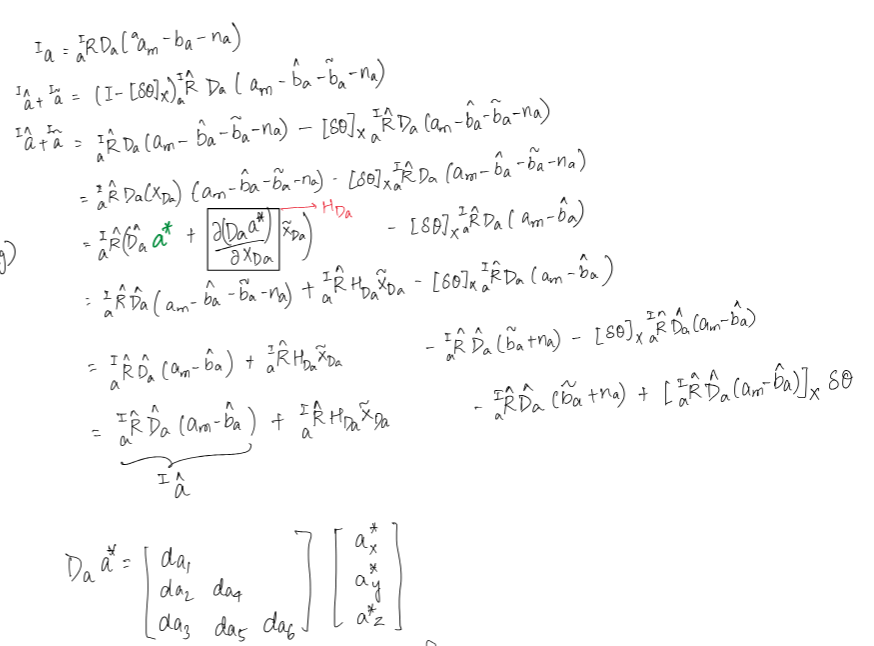
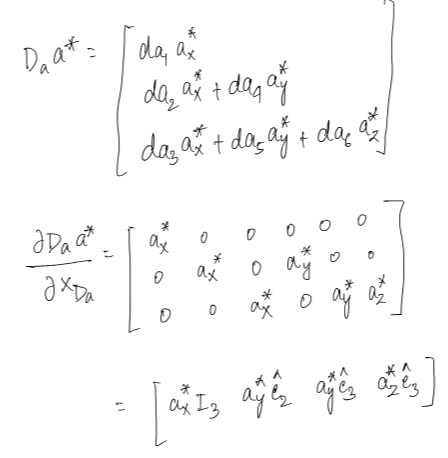

By summarizing the above equations, we have:

$$
\begin{bmatrix} {}^{I_k}\tilde{\boldsymbol{\omega}} \\ {}^{I_k}\tilde{\mathbf{a}} \end{bmatrix} = \begin{bmatrix} \mathbf{H}_b & \mathbf{H}_{in} \end{bmatrix} \begin{bmatrix} \tilde{\mathbf{x}}_b \\ \tilde{\mathbf{x}}_{in} \end{bmatrix} + \mathbf{H}_n \begin{bmatrix} \mathbf{n}_{dg} \\ \mathbf{n}_{da} \end{bmatrix}
$$

where we have defined:

$$
\mathbf{H}_b = \mathbf{H}_n = \begin{bmatrix} -{}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w & {}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g {}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a \\ \mathbf{0}_3 & -{}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_a \end{bmatrix}
$$

$$
\mathbf{H}_{in} = \begin{bmatrix} \mathbf{H}_w & \mathbf{H}_a & \mathbf{H}_{Iw} & \mathbf{H}_{Ia} & \mathbf{H}_g \end{bmatrix}
$$

$$
\mathbf{H}_w = \frac{\partial [{}^{I_k}\tilde{\boldsymbol{\omega}} \,\, {}^{I_k}\tilde{\mathbf{a}}]}{\partial \mathbf{x}_{Dw}} = \begin{bmatrix} {}^I_w\hat{\mathbf{R}}\mathbf{H}_{Dw} \\ \mathbf{0}_3 \end{bmatrix}
$$

$$
\mathbf{H}_a = \frac{\partial [{}^{I_k}\tilde{\boldsymbol{\omega}} \,\, {}^{I_k}\tilde{\mathbf{a}}]}{\partial \mathbf{x}_{Da}} = \begin{bmatrix} -{}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g {}^I_a\hat{\mathbf{R}}\mathbf{H}_{Da} \\ {}^I_a\hat{\mathbf{R}}\mathbf{H}_{Da} \end{bmatrix}
$$

$$
\mathbf{H}_{Iw} = \frac{\partial [{}^{I_k}\tilde{\boldsymbol{\omega}} \,\, {}^{I_k}\tilde{\mathbf{a}}]}{\partial {}^I_w\delta\boldsymbol{\theta}} = \begin{bmatrix} \lfloor {}^I\hat{\boldsymbol{\omega}} \rfloor \\ \mathbf{0}_3 \end{bmatrix}
$$

$$
\mathbf{H}_{Ia} = \frac{\partial [{}^{I_k}\tilde{\boldsymbol{\omega}} \,\, {}^{I_k}\tilde{\mathbf{a}}]}{\partial {}^I_a\delta\boldsymbol{\theta}} = \begin{bmatrix} -{}^I_a\hat{\mathbf{R}}\hat{\mathbf{D}}_w \hat{\mathbf{T}}_g \lfloor {}^I\hat{\mathbf{a}} \rfloor \\ \lfloor {}^I\hat{\mathbf{a}} \rfloor \end{bmatrix}
$$

$$
\mathbf{H}_g = \frac{\partial [{}^{I_k}\tilde{\boldsymbol{\omega}} \,\, {}^{I_k}\tilde{\mathbf{a}}]}{\partial \mathbf{x}_{Tg}} = \begin{bmatrix} -{}^I_w\hat{\mathbf{R}}\hat{\mathbf{D}}_w \mathbf{H}_{Tg} \\ \mathbf{0}_3 \end{bmatrix}
$$

We then linearize $\Delta\mathbf{R}_k, \Delta\mathbf{p}_k$ and $\Delta\mathbf{v}_k$. For the $\Delta\mathbf{R}_k$, we can get:

$$
\begin{aligned}
\Delta\mathbf{R}_k &= \exp(-{}^{I_k}\boldsymbol{\omega}\Delta t_k) \\
&= \exp(-({}^{I_k}\hat{\boldsymbol{\omega}} + {}^{I_k}\tilde{\boldsymbol{\omega}})\Delta t_k) \\
&\simeq \exp(-{}^{I_k}\hat{\boldsymbol{\omega}}\Delta t_k) \cdot \exp(-\mathbf{J}_r(-{}^{I_k}\hat{\boldsymbol{\omega}}\Delta t_k){}^{I_k}\tilde{\boldsymbol{\omega}}\Delta t_k) \\
&\simeq \underbrace{\exp(-\Delta\hat{\mathbf{R}}_k \mathbf{J}_r(-{}^{I_k}\hat{\boldsymbol{\omega}}\Delta t_k){}^{I_k}\tilde{\boldsymbol{\omega}}\Delta t_k)}_{\Delta\tilde{\mathbf{R}}_k} \exp(-{}^{I_k}\hat{\boldsymbol{\omega}}\Delta t_k)
\end{aligned}
$$

For the integration of $\Delta\mathbf{p}_k$, we get:

$$
\begin{aligned}
\Delta\mathbf{p}_k &= \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp({}^{I_k}\boldsymbol{\omega}\delta\tau) d\tau ds \cdot {}^{I_k}\mathbf{a} \\
&= \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp(({}^{I_k}\hat{\boldsymbol{\omega}} + {}^{I_k}\tilde{\boldsymbol{\omega}})\delta\tau) d\tau ds \cdot ({}^{I_k}\hat{\mathbf{a}} + {}^{I_k}\tilde{\mathbf{a}}) \\
&\simeq \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) \exp(\mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau){}^{I_k}\tilde{\boldsymbol{\omega}}\delta\tau) d\tau ds \cdot ({}^{I_k}\hat{\mathbf{a}} + {}^{I_k}\tilde{\mathbf{a}}) \\
&\simeq \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) (\mathbf{I} + \lfloor \mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau){}^{I_k}\tilde{\boldsymbol{\omega}}\delta\tau \rfloor ) d\tau ds \cdot ({}^{I_k}\hat{\mathbf{a}} + {}^{I_k}\tilde{\mathbf{a}})
\end{aligned}
$$

$$
\begin{aligned}
&\simeq \underbrace{\int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) d\tau ds}_{\boldsymbol{\Xi}_2} \cdot {}^{I_k}\hat{\mathbf{a}} \\
&- \underbrace{\int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) \lfloor {}^{I_k}\hat{\mathbf{a}} \rfloor \mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) d\tau ds}_{\boldsymbol{\Xi}_4} \cdot {}^{I_k}\tilde{\boldsymbol{\omega}} \\
&+ \underbrace{\int_{t_k}^{t_{k+1}} \int_{t_k}^{s} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) d\tau ds}_{\boldsymbol{\Xi}_2} \cdot {}^{I_k}\tilde{\mathbf{a}}
\end{aligned}
$$

$$
= \Delta\hat{\mathbf{p}}_k \underbrace{- \boldsymbol{\Xi}_4 {}^{I_k}\tilde{\boldsymbol{\omega}} + \boldsymbol{\Xi}_2 {}^{I_k}\tilde{\mathbf{a}}}_{\Delta\tilde{\mathbf{p}}_k}
$$

$$
= \Delta\hat{\mathbf{p}}_k + \Delta\tilde{\mathbf{p}}_k
$$

For the integration of $\Delta \mathbf{v}_k$, we get:

$$
\begin{aligned}
\Delta \mathbf{v}_k &= \int_{t_k}^{t_{k+1}} \exp({}^{I_k}\boldsymbol{\omega}\delta\tau) d\tau \cdot {}^{I_k}\mathbf{a} \\
&= \int_{t_k}^{t_{k+1}} \exp(({}^{I_k}\hat{\boldsymbol{\omega}} + {}^{I_k}\tilde{\boldsymbol{\omega}})\delta\tau) d\tau \cdot ({}^{I_k}\hat{\mathbf{a}} + {}^{I_k}\tilde{\mathbf{a}}) \\
&\simeq \int_{t_k}^{t_{k+1}} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) \exp(\mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau){}^{I_k}\tilde{\boldsymbol{\omega}}\delta\tau) d\tau \cdot ({}^{I_k}\hat{\mathbf{a}} + {}^{I_k}\tilde{\mathbf{a}}) \\
&\simeq \int_{t_k}^{t_{k+1}} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) (\mathbf{I} + \lfloor \mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau){}^{I_k}\tilde{\boldsymbol{\omega}}\delta\tau \rfloor ) d\tau \cdot ({}^{I_k}\hat{\mathbf{a}} + {}^{I_k}\tilde{\mathbf{a}}) \\
&\simeq \underbrace{\int_{t_k}^{t_{k+1}} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) d\tau}_{\boldsymbol{\Xi}_1} \cdot {}^{I_k}\hat{\mathbf{a}} \\
&- \underbrace{\int_{t_k}^{t_{k+1}} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) \lfloor {}^{I_k}\hat{\mathbf{a}} \rfloor \mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) d\tau}_{\boldsymbol{\Xi}_3} \cdot {}^{I_k}\tilde{\boldsymbol{\omega}} \\
&+ \underbrace{\int_{t_k}^{t_{k+1}} \exp({}^{I_k}\hat{\boldsymbol{\omega}}\delta\tau) d\tau}_{\boldsymbol{\Xi}_1} \cdot {}^{I_k}\tilde{\mathbf{a}}
\end{aligned}
$$

$$
= \Delta \hat{\mathbf{v}}_k \underbrace{- \boldsymbol{\Xi}_3 {}^{I_k}\tilde{\boldsymbol{\omega}} + \boldsymbol{\Xi}_1 {}^{I_k}\tilde{\mathbf{a}}}_{\Delta \tilde{\mathbf{v}}_k}
$$

$$
= \Delta \hat{\mathbf{v}}_k + \Delta \tilde{\mathbf{v}}_k
$$

where $\delta\tau = t_\tau - t_k$ and $\boldsymbol{\Xi}_i, i = 1 \dots 4$ are shown in the **Integration Component Definitions** section. $\mathbf{J}_r(-{}^{I_k}\hat{\boldsymbol{\omega}}\Delta t_k)$ is the right Jacobian of $SO(3)$. In summary, we have the following linearized integration components (see **Integration Component Definitions**):

$$
\Delta\mathbf{R}_k = \Delta\tilde{\mathbf{R}}_k\Delta\hat{\mathbf{R}}_k \triangleq \exp\left(-\Delta\hat{\mathbf{R}}_k\mathbf{J}_r(\Delta\boldsymbol{\theta}_k){}^{I_k}\tilde{\boldsymbol{\omega}}\Delta t_k\right) \Delta\hat{\mathbf{R}}_k
$$

$$
\Delta\mathbf{p}_k = \Delta\hat{\mathbf{p}}_k + \Delta\tilde{\mathbf{p}}_k \triangleq \Delta\hat{\mathbf{p}}_k - \boldsymbol{\Xi}_4 {}^{I_k}\tilde{\boldsymbol{\omega}} + \boldsymbol{\Xi}_2 {}^{I_k}\tilde{\mathbf{a}}
$$

$$
\Delta\mathbf{v}_k = \Delta\hat{\mathbf{v}}_k + \Delta\tilde{\mathbf{v}}_k \triangleq \Delta\hat{\mathbf{v}}_k - \boldsymbol{\Xi}_3 {}^{I_k}\tilde{\boldsymbol{\omega}} + \boldsymbol{\Xi}_1 {}^{I_k}\tilde{\mathbf{a}}
$$

where $\mathbf{J}_r(\Delta\boldsymbol{\theta}_k) \triangleq \mathbf{J}_r(-{}^{I_k}\hat{\boldsymbol{\omega}}_k\Delta t_k)$ and $\boldsymbol{\Xi}_3$ and $\boldsymbol{\Xi}_4$ are defined as:

$$
\boldsymbol{\Xi}_3 = \int_{t_k}^{t_{k+1}} {}^{I_k}_{I_\tau}\mathbf{R} \lfloor {}^{I_\tau}\mathbf{a} \rfloor \mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}_k \delta\tau) \delta\tau \, d\tau
$$

$$
\boldsymbol{\Xi}_4 = \int_{t_k}^{t_{k+1}} \int_{t_k}^{s} {}^{I_k}_{I_\tau}\mathbf{R} \lfloor {}^{I_\tau}\mathbf{a} \rfloor \mathbf{J}_r({}^{I_k}\hat{\boldsymbol{\omega}}_k \delta\tau) \delta\tau \, d\tau ds
$$

#### Nominal state Kinematics
Under the assumption of constant ${}^{I_k}\hat{\boldsymbol{\omega}}$ and ${}^{I_k}\hat{\mathbf{a}}$, the above equations are also constant over the time interval. The mean propagation for the new state at $t_{k+1}$ can be written after taking the expectation:

$$
{}^{I_{k+1}}_G\hat{\mathbf{R}} \simeq \Delta\mathbf{R}_k {}^{I_k}_G\hat{\mathbf{R}}
$$

$$
{}^G\hat{\mathbf{p}}_{I_{k+1}} \simeq {}^G\hat{\mathbf{p}}_{I_k} + {}^G\hat{\mathbf{v}}_{I_k}\Delta t_k + {}_G^{I_k}\hat{\mathbf{R}}^\top \boldsymbol{\Xi}_2 {}^{I_k}\hat{\mathbf{a}} - \frac{1}{2}{}^G\mathbf{g}\Delta t_k^2
$$

$$
{}^G\hat{\mathbf{v}}_{I_{k+1}} \simeq {}^G\hat{\mathbf{v}}_{I_k} + {}_G^{I_k}\hat{\mathbf{R}}^\top \boldsymbol{\Xi}_1 {}^{I_k}\hat{\mathbf{a}} - {}^G\mathbf{g}\Delta t_k
$$

$$
\hat{\mathbf{b}}_{g_{k+1}} = \hat{\mathbf{b}}_{g_k}
$$

$$
\hat{\mathbf{b}}_{a_{k+1}} = \hat{\mathbf{b}}_{a_k}
$$

#### Error state Kinematics

Hence, the linearized IMU system is:

$$
\delta\boldsymbol{\theta}_{k+1} \simeq \Delta\hat{\mathbf{R}}_k \delta\boldsymbol{\theta}_k + \Delta\hat{\mathbf{R}}_k \mathbf{J}_r(\Delta\boldsymbol{\theta}_k) \Delta t_k {}^{I_k}\tilde{\boldsymbol{\omega}}
$$

$$
{}^G\tilde{\mathbf{p}}_{I_{k+1}} \simeq {}^G\tilde{\mathbf{p}}_{I_k} + {}^G\tilde{\mathbf{v}}_{I_k}\Delta t_k - {}^I_G\hat{\mathbf{R}}^\top \lfloor \Delta\hat{\mathbf{p}}_k \rfloor \delta\boldsymbol{\theta}_k + {}^I_G\hat{\mathbf{R}}^\top \left( -\boldsymbol{\Xi}_4 {}^{I_k}\tilde{\boldsymbol{\omega}} + \boldsymbol{\Xi}_2 {}^{I_k}\tilde{\mathbf{a}} \right)
$$

$$
{}^G\tilde{\mathbf{v}}_{I_{k+1}} \simeq {}^G\tilde{\mathbf{v}}_{I_k} - {}^I_G\hat{\mathbf{R}}^\top \lfloor \Delta\hat{\mathbf{v}}_k \rfloor \delta\boldsymbol{\theta}_k + {}^I_G\hat{\mathbf{R}}^\top \left( -\boldsymbol{\Xi}_3 {}^{I_k}\tilde{\boldsymbol{\omega}} + \boldsymbol{\Xi}_1 {}^{I_k}\tilde{\mathbf{a}} \right)
$$

The overall linearized error state system is:

$$
\tilde{\mathbf{x}}_{I_{k+1}} \simeq \boldsymbol{\Phi}_{I(k+1,k)}\tilde{\mathbf{x}}_{I_k} + \mathbf{G}_{Ik}\mathbf{n}_{dk}
$$

$$
\boldsymbol{\Phi}_{I(k+1,k)} = \begin{bmatrix} \boldsymbol{\Phi}_{nn} & \boldsymbol{\Phi}_{wa}\mathbf{H}_b & \boldsymbol{\Phi}_{wa}\mathbf{H}_{in} \\ \mathbf{0}_{6 \times 9} & \mathbf{I}_6 & \mathbf{0}_{6 \times 24} \\ \mathbf{0}_{24 \times 9} & \mathbf{0}_{24 \times 6} & \mathbf{I}_{24} \end{bmatrix}
$$

$$
\mathbf{G}_{Ik} = \begin{bmatrix} \boldsymbol{\Phi}_{wa}\mathbf{H}_n & \mathbf{0}_{9 \times 6} \\ \mathbf{0}_6 & \mathbf{I}_6 \Delta t_k \\ \mathbf{0}_{24 \times 6} & \mathbf{0}_{24 \times 6} \end{bmatrix}
$$

where $\boldsymbol{\Phi}_{I(k+1,k)}$ and $\mathbf{G}_{Ik}$ are the state transition matrix and noise Jacobians for IMU dynamic model; $\mathbf{H}_b$, $\mathbf{H}_{in}$ and $\mathbf{H}_n$ are Jacobians related to bias, IMU intrinsics and noises, which can be found from previous derivations; $\mathbf{n}_{dk} = [\mathbf{n}_{dg}^\top \,\, \mathbf{n}_{da}^\top \,\, \mathbf{n}_{dwg}^\top \,\, \mathbf{n}_{dwa}^\top]^\top$ is the discrete-time IMU noises; $\boldsymbol{\Phi}_{nn}$ and $\boldsymbol{\Phi}_{wa}$ can be computed as:

$$
\boldsymbol{\Phi}_{nn} = \begin{bmatrix} \Delta\hat{\mathbf{R}}_k & \mathbf{0}_3 & \mathbf{0}_3 \\ -{}^I_G\hat{\mathbf{R}}^\top \lfloor \Delta\hat{\mathbf{p}}_k \rfloor & \mathbf{I}_3 & \mathbf{I}_3 \Delta t_k \\ -{}^I_G\hat{\mathbf{R}}^\top \lfloor \Delta\hat{\mathbf{v}}_k \rfloor & \mathbf{0}_3 & \mathbf{I}_3 \end{bmatrix}
$$

$$
\boldsymbol{\Phi}_{wa} = \begin{bmatrix} \Delta\hat{\mathbf{R}}_k \mathbf{J}_r(\Delta\boldsymbol{\theta}_k)\Delta t_k & \mathbf{0}_3 \\ -{}^I_G\hat{\mathbf{R}}^\top \boldsymbol{\Xi}_4 & {}^I_G\hat{\mathbf{R}}^\top \boldsymbol{\Xi}_2 \\ -{}^I_G\hat{\mathbf{R}}^\top \boldsymbol{\Xi}_3 & {}^I_G\hat{\mathbf{R}}^\top \boldsymbol{\Xi}_1 \end{bmatrix}
$$

Note that $\mathbf{n}_{d*} \sim \mathcal{N}(\mathbf{0}, \frac{\sigma_*^2 \mathbf{I}_3}{\Delta t_k})$ and hence the covariance for $\mathbf{n}_{dI}$ can be written as:

$$
\mathbf{Q}_{dI} = \begin{bmatrix} \frac{\sigma_g^2}{\Delta t_k}\mathbf{I}_3 & \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 \\ \mathbf{0}_3 & \frac{\sigma_a^2}{\Delta t_k}\mathbf{I}_3 & \mathbf{0}_3 & \mathbf{0}_3 \\ \mathbf{0}_3 & \mathbf{0}_3 & \sigma_{wg}^2\Delta t_k \mathbf{I}_3 & \mathbf{0}_3 \\ \mathbf{0}_3 & \mathbf{0}_3 & \mathbf{0}_3 & \sigma_{wa}^2\Delta t_k \mathbf{I}_3 \end{bmatrix}
$$

Finally, the covariance propagation can be derived as:

$$
\mathbf{P}_{k+1} = \boldsymbol{\Phi}_{I(k+1,k)} \mathbf{P}_k \boldsymbol{\Phi}_{I(k+1,k)}^\top + \mathbf{G}_{Ik} \mathbf{Q}_{dI} \mathbf{G}_{Ik}^\top
$$

#### Integration Component Definitions

When deriving the components, we drop the subscripts for simplicity. As we define angular velocity $\hat{\omega} = || {}^I\hat{\boldsymbol{\omega}} ||$, rotation axis $\mathbf{k} = {}^I\hat{\boldsymbol{\omega}} / || {}^I\hat{\boldsymbol{\omega}} ||$, and the small interval we are integrating over as $\delta t$. The first integration we need is:

$$
\boldsymbol{\Xi}_1 = \mathbf{I}_3 \delta t + \frac{1 - \cos(\hat{\omega} \delta t)}{\hat{\omega}} \lfloor \hat{\mathbf{k}} \rfloor + \left( \delta t - \frac{\sin(\hat{\omega} \delta t)}{\hat{\omega}} \right) \lfloor \hat{\mathbf{k}} \rfloor^2
$$

The second integration we need is:

$$
\boldsymbol{\Xi}_2 = \frac{1}{2} \delta t^2 \mathbf{I}_3 + \frac{\hat{\omega} \delta t - \sin(\hat{\omega} \delta t)}{\hat{\omega}^2} \lfloor \hat{\mathbf{k}} \rfloor + \left( \frac{1}{2} \delta t^2 - \frac{1 - \cos(\hat{\omega} \delta t)}{\hat{\omega}^2} \right) \lfloor \hat{\mathbf{k}} \rfloor^2
$$

The third integration can be written as:

$$
\begin{aligned}
\boldsymbol{\Xi}_3 &= \frac{1}{2} \delta t^2 \lfloor \hat{\mathbf{a}} \rfloor + \frac{\sin(\hat{\omega} \delta t_i) - \hat{\omega} \delta t}{\hat{\omega}^2} \lfloor \hat{\mathbf{a}} \rfloor \lfloor \hat{\mathbf{k}} \rfloor \\
&+ \frac{\sin(\hat{\omega} \delta t) - \hat{\omega} \delta t \cos(\hat{\omega} \delta t)}{\hat{\omega}^2} \lfloor \hat{\mathbf{k}} \rfloor \lfloor \hat{\mathbf{a}} \rfloor \\
&+ \left( \frac{1}{2} \delta t^2 - \frac{1 - \cos(\hat{\omega} \delta t)}{\hat{\omega}^2} \right) \lfloor \hat{\mathbf{a}} \rfloor \lfloor \hat{\mathbf{k}} \rfloor^2 \\
&+ \left( \frac{1}{2} \delta t^2 + \frac{1 - \cos(\hat{\omega} \delta t) - \hat{\omega} \delta t \sin(\hat{\omega} \delta t)}{\hat{\omega}^2} \right) \lfloor \hat{\mathbf{k}} \rfloor^2 \lfloor \hat{\mathbf{a}} \rfloor \\
&+ \left( \frac{1}{2} \delta t^2 + \frac{1 - \cos(\hat{\omega} \delta t) - \hat{\omega} \delta t \sin(\hat{\omega} \delta t)}{\hat{\omega}^2} \right) \hat{\mathbf{k}}^\top \hat{\mathbf{a}} \lfloor \hat{\mathbf{k}} \rfloor \\
&- \frac{3 \sin(\hat{\omega} \delta t) - 2 \hat{\omega} \delta t - \hat{\omega} \delta t \cos(\hat{\omega} \delta t)}{\hat{\omega}^2} \hat{\mathbf{k}}^\top \hat{\mathbf{a}} \lfloor \hat{\mathbf{k}} \rfloor^2
\end{aligned}
$$

The fourth integration we need is:

$$
\begin{aligned}
\boldsymbol{\Xi}_4 &= \frac{1}{6} \delta t^3 \lfloor \hat{\mathbf{a}} \rfloor + \frac{2(1 - \cos(\hat{\omega} \delta t)) - (\hat{\omega}^2 \delta t^2)}{2 \hat{\omega}^3} \lfloor \hat{\mathbf{a}} \rfloor \lfloor \hat{\mathbf{k}} \rfloor \\
&+ \left( \frac{2(1 - \cos(\hat{\omega} \delta t)) - \hat{\omega} \delta t \sin(\hat{\omega} \delta t)}{\hat{\omega}^3} \right) \lfloor \hat{\mathbf{k}} \rfloor \lfloor \hat{\mathbf{a}} \rfloor \\
&+ \left( \frac{\sin(\hat{\omega} \delta t) - \hat{\omega} \delta t}{\hat{\omega}^3} + \frac{\delta t^3}{6} \right) \lfloor \hat{\mathbf{a}} \rfloor \lfloor \hat{\mathbf{k}} \rfloor^2 \\
&+ \frac{\hat{\omega} \delta t - 2 \sin(\hat{\omega} \delta t) + \frac{1}{6}(\hat{\omega} \delta t)^3 + \hat{\omega} \delta t \cos(\hat{\omega} \delta t)}{\hat{\omega}^3} \lfloor \hat{\mathbf{k}} \rfloor^2 \lfloor \hat{\mathbf{a}} \rfloor \\
&+ \frac{\hat{\omega} \delta t - 2 \sin(\hat{\omega} \delta t) + \frac{1}{6}(\hat{\omega} \delta t)^3 + \hat{\omega} \delta t \cos(\hat{\omega} \delta t)}{\hat{\omega}^3} \hat{\mathbf{k}}^\top \hat{\mathbf{a}} \lfloor \hat{\mathbf{k}} \rfloor \\
&+ \frac{4 \cos(\hat{\omega} \delta t) - 4 + (\hat{\omega} \delta t)^2 + \hat{\omega} \delta t \sin(\hat{\omega} \delta t)}{\hat{\omega}^3} \hat{\mathbf{k}}^\top \hat{\mathbf{a}} \lfloor \hat{\mathbf{k}} \rfloor^2
\end{aligned}
$$

#### Difference between Discrete and Analytical Propagation
##### Sensor model assumed
The discrete page explicitly says it uses a simplified discrete inertial model which does not include IMU intrinsic parameters. Its propagation uses only raw gyro/accel measurements plus bias and white noise. The analytical page instead assumes the full corrected IMU model with scale/misalignment matrices, sensor-frame rotations R, and gravity sensitivity , and it even includes those intrinsic parameters in the state.

##### What is assumed constant over [tk,tk+1]
In the discrete derivation, the assumption is: the measurement sample at tk is held constant until tk+1. So it uses 
ωm,k and am,k directly as zero-order-held inputs. In the analytical derivation, the assumption is that the corrected quantities I_a, I_w are constant over the interval, after applying the intrinsic model and bias correction. 

##### How translation is treated during rotation

This is the most important practical difference. In the discrete derivation, position and velocity are updated such that translational acceleration is effectively applied through the start-of-interval orientation. In the analytical derivation, the rotation changes during the interval inside the integrals terms. So the analytical derivation keeps the effect of within-step rotation on v and p, while the discrete one uses the simpler zeroth-order approximation.

How errors/noise are modeled

In the discrete derivation, the perturbations are simple depending on bias and noises. In analytical case the noise depends on intrinsics parameters as well.

Derivation viewpoint

The discrete page derives the covariance propagation by perturbing an already discretized one-step update. The analytical page starts from the continuous-time kinematics, linearizes the corrected IMU readings, and only then integrates them into a discrete transition. So the difference is also “discretize first, then linearize” versus “linearize continuous corrected dynamics, then integrate.”